# resample — Polynomial-interpolation resampling

Resample a scalar time series at a new sampling rate via local polynomial
interpolation, reproducing the TISEAN `resample` program.

```python
from nolitisea.utils.resample import resample
resample(series, sampletime=0.5, order=4)
```

- `sampletime` — new sampling interval in units of the old one (`< 1`
  up-samples, `> 1` down-samples).
- `order` — degree of the interpolating polynomial; `order + 1` consecutive
  samples are used for each local fit (default 4 → 5-point window).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.utils.resample import resample

# --- test signal: sine + slow drift, 200 samples ---
n = 200
t = np.arange(n, dtype=float)
x = np.sin(2 * np.pi * t / 20.0) + 0.1 * t / n

print(f"input: {n} samples")

input: 200 samples


## Up-sampling (sampletime < 1)

With `sampletime=0.5` the output has roughly twice as many points.  The
interpolated values track the true continuous signal closely.

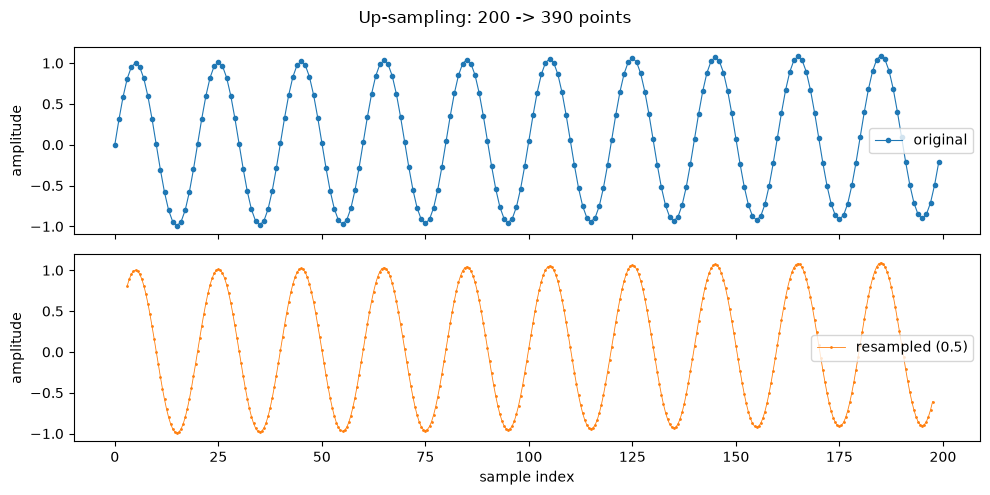

up-sampled: 390 points (input 200)


In [2]:
y_up = resample(x, sampletime=0.5, order=4)
t_up = np.arange(3.0, n - 2, 0.5)          # output time grid

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, x, "o-", ms=3, lw=0.8, label="original")
axes[0].set_ylabel("amplitude")
axes[0].legend()
axes[1].plot(t_up, y_up, ".-", ms=2, lw=0.6, color="C1", label="resampled (0.5)")
axes[1].set_xlabel("sample index")
axes[1].set_ylabel("amplitude")
axes[1].legend()
fig.suptitle(f"Up-sampling: 200 -> {y_up.size} points")
plt.tight_layout()
plt.show()

print(f"up-sampled: {y_up.size} points (input {n})")

## Down-sampling (sampletime > 1)

With `sampletime=2.0` the output has roughly half as many points.

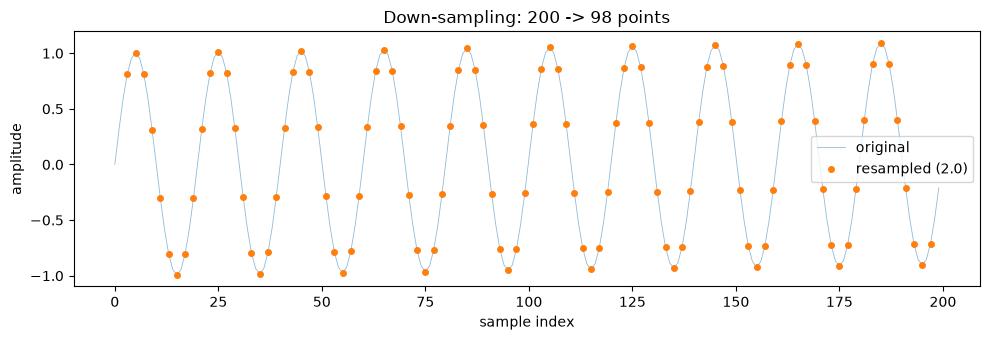

down-sampled: 98 points (input 200)


In [3]:
y_dn = resample(x, sampletime=2.0, order=4)
t_dn = np.arange(3.0, n - 2, 2.0)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t, x, "-", lw=0.6, alpha=0.5, label="original")
ax.plot(t_dn, y_dn, "o", ms=4, color="C1", label="resampled (2.0)")
ax.set_xlabel("sample index")
ax.set_ylabel("amplitude")
ax.set_title(f"Down-sampling: 200 -> {y_dn.size} points")
ax.legend()
plt.tight_layout()
plt.show()

print(f"down-sampled: {y_dn.size} points (input {n})")

## Interpolation order

Higher `order` uses more neighbours and gives a smoother fit, but requires
more data.  At integer time points the original samples are recovered exactly.

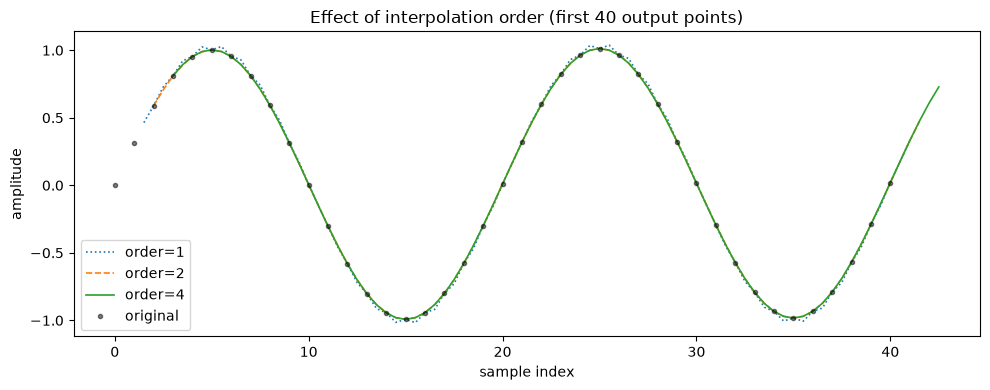

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

for order, ls in [(1, ":"), (2, "--"), (4, "-")]:
    y = resample(x, sampletime=0.5, order=order)
    horder = order + 1
    tt = np.arange((horder + 1) / 2.0, n - horder // 2, 0.5)
    ax.plot(tt[:80], y[:80], ls, lw=1.2, label=f"order={order}")

ax.plot(t[:41], x[:41], "ko", ms=3, alpha=0.5, label="original")
ax.set_xlabel("sample index")
ax.set_ylabel("amplitude")
ax.set_title("Effect of interpolation order (first 40 output points)")
ax.legend()
plt.tight_layout()
plt.show()

## Accuracy check

For a pure sine the 4th-order interpolant has negligible error; the 1st-order
(linear extrapolation at half-integer times) is noticeably worse.

In [5]:
y4 = resample(x, sampletime=0.5, order=4)
t4 = np.arange(3.0, n - 2, 0.5)
true4 = np.sin(2 * np.pi * t4 / 20.0) + 0.1 * t4 / n
err4 = np.abs(y4 - true4)

y1 = resample(x, sampletime=0.5, order=1)
t1 = np.arange(1.5, n - 1, 0.5)
true1 = np.sin(2 * np.pi * t1 / 20.0) + 0.1 * t1 / n
err1 = np.abs(y1 - true1)

print(f"order=4  max error: {err4.max():.2e}")
print(f"order=1  max error: {err1.max():.2e}")

order=4  max error: 3.54e-05
order=1  max error: 3.68e-02


## Resampling a Lorenz component

A practical use case: the Lorenz `x` component is generated at a default
sampling interval of 0.03; resampling at `sampletime=0.5` doubles the output
rate for finer-grained analysis.

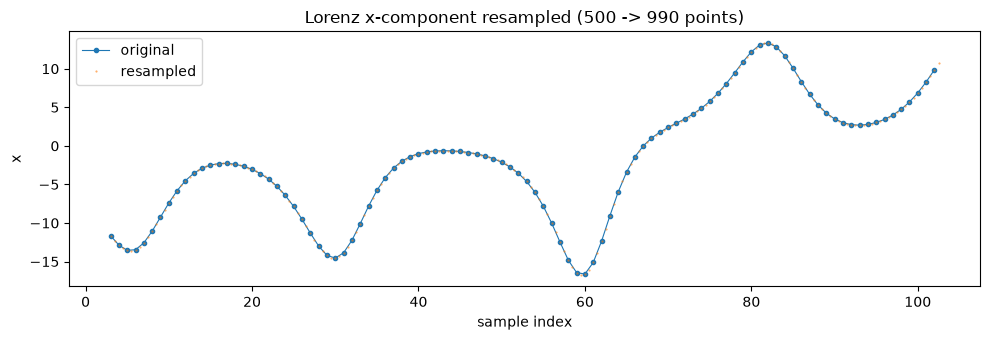

In [ ]:
from nolitisea.generate.lorenz import lorenz

_, states = lorenz(length=500)
lx = states[:, 0]

lx_up = resample(lx, sampletime=0.5, order=4)
t_orig = np.arange(3.0, 500 - 2, 1.0)
t_res = np.arange(3.0, 500 - 2, 0.5)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_orig[:100], lx[3:103], "o-", ms=3, lw=0.8, label="original")
ax.plot(t_res[:200], lx_up[:200], ".", ms=1, lw=0.4, alpha=0.7, label="resampled")
ax.set_xlabel("sample index")
ax.set_ylabel("x")
ax.set_title(f"Lorenz x-component resampled (500 -> {lx_up.size} points)")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

- `resample(series, sampletime, order)` resamples a 1-D series using local
  polynomial interpolation: `order+1` consecutive samples fit a degree-`order`
  polynomial, evaluated at equally spaced fractional positions.
- `sampletime < 1` up-samples (more points), `> 1` down-samples (fewer).
- Higher `order` gives smoother results but needs more data; at integer time
  points the original samples are recovered exactly.